# Putting It All Together

Every notebook in this series saved its evaluation metrics to `results/*.json` on the
same train/test split. Let's line them all up.

| Method | Stage | Notebook |
|---|---|---|
| Popularity | baseline | `00_data_and_evaluation` |
| ALS (matrix factorization) | Retrieval | `01_retrieval_als` |
| Item2Vec + mean pooling | Retrieval | `02_retrieval_embedding_similarity` |
| ALS + LightGBM re-ranking | Retrieval + Ranking | `03_ranking_gbdt` |
| Two-Tower neural network | Retrieval | `04_retrieval_two_tower` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rec_utils as ru

ru.setup_plot_style()

results = ru.load_all_results()
df = pd.DataFrame(results).T
df = df.reindex(["00_popularity", "01_als", "02_item2vec", "03_gbdt_ranking", "04_two_tower"])
df

,recall@10,ndcg@10,recall@20,ndcg@20
00_popularity,0.051667,0.029234,0.085000,0.037774
01_als,0.108333,0.062281,0.168333,0.077169
02_item2vec,0.121667,0.055420,0.176667,0.069363
03_gbdt_ranking,0.115000,0.060645,0.193333,0.080500
04_two_tower,0.095000,0.051513,0.163333,0.068416


## Visual comparison

A fixed color per method (never reassigned, even if we later sort or filter) — so the
same method always reads as the same color across every chart you make from this data.

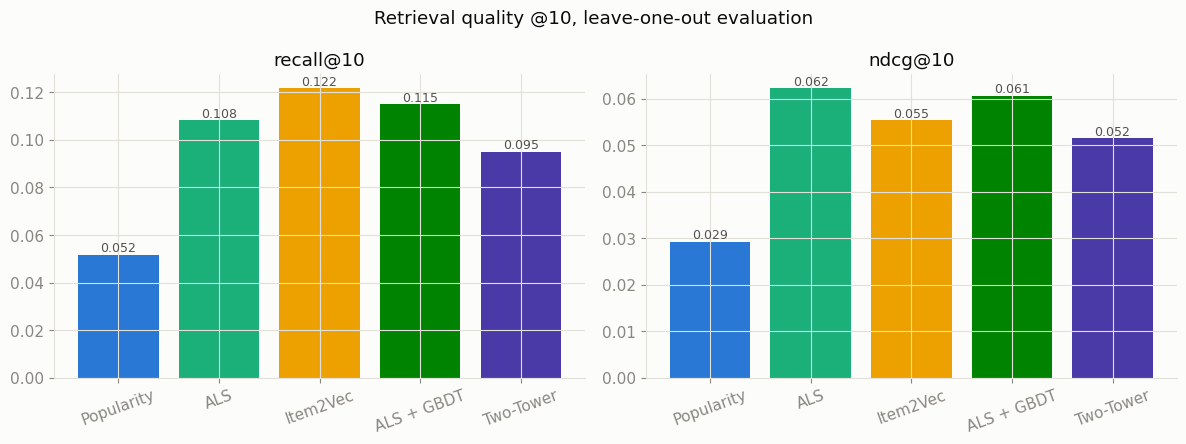

In [2]:
METHOD_LABELS = {
    "00_popularity": "Popularity",
    "01_als": "ALS",
    "02_item2vec": "Item2Vec",
    "03_gbdt_ranking": "ALS + GBDT",
    "04_two_tower": "Two-Tower",
}
METHOD_COLORS = dict(zip(METHOD_LABELS, ru.GENRE_COLORS))  # fixed identity -> color mapping

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric in zip(axes, ["recall@10", "ndcg@10"]):
    values = df[metric]
    colors = [METHOD_COLORS[m] for m in values.index]
    bars = ax.bar([METHOD_LABELS[m] for m in values.index], values.values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
    for b, v in zip(bars, values.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, color=ru.INK_SECONDARY)

fig.suptitle("Retrieval quality @10, leave-one-out evaluation")
fig.tight_layout()
plt.show()

## How to read this

- **Every personalized method clearly beats popularity** — that's the whole point: they
  actually use who the user is, not just what's globally trending.
- **ALS, Item2Vec, and Two-Tower are all genuine retrieval methods**, directly comparable
  to each other — they all answer "which ~50 items should we even consider for this
  user?" from scratch.
- **`ALS + GBDT` is not quite the same kind of comparison**: it reorders *ALS's own
  candidate list*, so its recall is capped by whatever ALS already put in that list. Its
  value shows up more clearly at higher K (recall@20 jumps from ALS's 0.168 to 0.193) —
  the ranker is better at pulling a correct-but-not-top-ranked candidate further up, not
  at finding candidates ALS missed entirely.
- On this small synthetic dataset the three retrieval methods land in a similar range —
  that's expected. The interesting differences between them are architectural (how they
  handle new users/items, how expensive they are to update, how easily they take
  additional features), not raw accuracy on 400 items.

## Where to go from here

- **Real data**: try the same notebooks against [MovieLens](https://grouplens.org/datasets/movielens/)
  or any implicit-feedback dataset you have — swap out `rec_utils.generate_synthetic_data()`
  for a real loader and everything downstream (splitting, metrics, models) works unchanged.
- **Serving retrieval at scale**: once you have item embeddings, look at approximate
  nearest-neighbor libraries (FAISS, ScaNN, HNSW) instead of the brute-force dot product
  we used here — this is exactly the ANN index a Two-Tower item tower feeds in production.
- **Combine retrieval sources**: real systems often merge candidates from *several*
  retrieval methods (e.g. ALS + Item2Vec + "trending now") before ranking, rather than
  picking just one.
- **Sequence-aware ranking/retrieval**: the Two-Tower notebook already used sequential
  (context -> next item) examples; the natural next step is a Transformer-based session
  encoder instead of mean-pooling (e.g. SASRec, BERT4Rec).
- **Richer ranking features**: the GBDT notebook used simple, almost toy features —
  production rankers lean heavily on recency, cross-features (user-genre affinity learned
  independently), and multiple upstream retrieval scores as inputs.